In [1]:
import kwant
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eig
from scipy.optimize import fmin
import os
from tqdm import tqdm
from joblib import Parallel, delayed
import matplotlib.patches as mpatches
from scipy.integrate import simpson  
from joblib import Parallel, delayed
import matplotlib.cm as cm
import matplotlib.colors as colors
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import pandas as pd

In [101]:
def gr_L(T_l, A_l, check_tol=1e-6):
    N = T_l.shape[0]                # 从输入矩阵自动获取维度
    I = np.eye(N)
    T_l_inv = np.linalg.inv(T_l)
    Tmat = np.block([
        [T_l_inv @ A_l, -T_l_inv @ T_l.conj().T],
        [I, np.zeros((N, N))]
    ])

    eigvals, eigvecs = eig(Tmat)

    idx = np.argsort(np.abs(eigvals))
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    lambdas = eigvals[:N]
    vecs = eigvecs[:, :N]

    S1 = vecs[:N, :]
    S2 = vecs[N:, :]

    gL = np.linalg.inv(A_l - T_l @ S1 @ np.linalg.inv(S2))
    return gL

def gr_L_keni(T_l, A_l, tol=1e-16):
    N = T_l.shape[0]
    I = np.eye(N)

    A = np.block([
        [np.zeros((N, N)), I],
        [-T_l.conj().T, A_l]
    ])

    B = np.block([
        [I, np.zeros((N, N))],
        [np.zeros((N, N)), T_l]
    ])

    eigvals, eigvecs = eig(A, B)

    lambdas = []
    modes = []

    for i, lam in enumerate(eigvals):
        if np.abs(lam) > 1 + tol:   # 衰减模式
            x = eigvecs[:N, i]
            x /= np.linalg.norm(x)
            lambdas.append(lam)
            modes.append(x)

    X = np.column_stack(modes)
    Lambda = np.diag(lambdas)
    #print(Lambda.shape,X.shape)
    F = X @ Lambda @ np.linalg.inv(X)

    gL = np.linalg.inv(A_l - T_l @ F)

    return gL


def zinengr_L(T_LD_wei, gr_L_wei):
    return T_LD_wei.conj().T @ gr_L_wei @ T_LD_wei

In [68]:
def H_onstie(weineng):
    # 返回二维数组 (1x1)
    return np.array([[weineng]], dtype=complex)

def H_hop(t):
    # 返回二维数组 (1x1)
    return np.array([[t]], dtype=complex)

# 参数
weineng_q = 1
weineng_r = 1
weineng_l = 1
t = 1

H_q = H_onstie(weineng_q)          
T_21 = H_hop(t)                   

H_l = H_onstie(weineng_l)           
T_l = H_hop(t).conj().T          
T_LD = T_l

H_r = H_onstie(weineng_r)       
T_r = H_hop(t)                    
T_RD = T_r.conj().T                

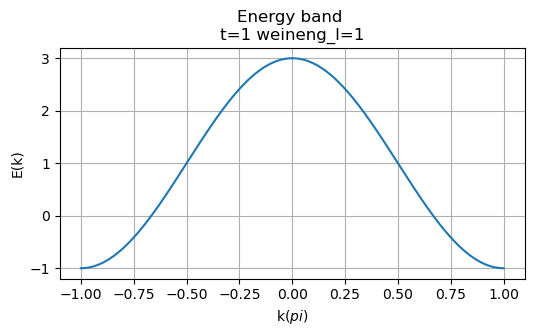

In [69]:
def Hk(k, H, T):
    return H + T * np.exp(-1j * k) + T.conj().T * np.exp(1j * k)
ks1 = np.linspace(-1*np.pi, 1*np.pi, 5001)
energies1 = []
for k in ks1:
    H_k = Hk(k, H_l, T_l)
    evals1 = np.linalg.eigvalsh(H_k)
    energies1.append(evals1)

# 转换为数组，形状 (len(ks1), 本征值数目)
energies1 = np.array(energies1)   # shape (5001, 1)
# 如果是多带，可转置为 (本征值数目, k点数) 方便逐带绘制
energies1 = energies1.T            # 现在 shape (1, 5001)

# ---------- 绘图 ----------
plt.figure(figsize=(6, 3))
for band in energies1:   # 若有多带，这里会分别画
    plt.plot(ks1/np.pi, band, lw=1.5)
plt.xlabel(r'k($pi$)')
plt.ylabel('E(k)')
plt.title('Energy band '+'\n'+rf't={t}'+ rf' weineng_l={weineng_l}')
plt.grid(True)
plt.show()

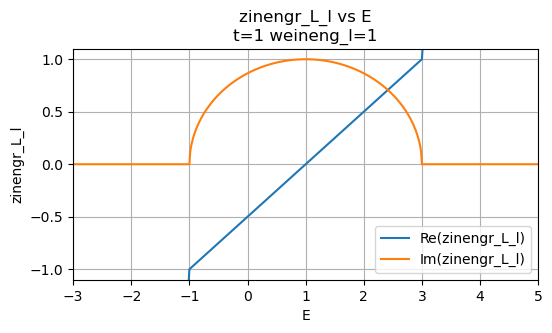

In [104]:
# ---------- 扫描 E ----------
E_array = np.linspace(-3, 5, 601)   # 601 个点，保证光滑
eta = 1e-9
real_part = []
imag_part = []

for E in E_array:
    A_l = (E + 1j*eta) * np.eye(1, dtype=complex) - H_l
    gr_l_val = gr_L_keni(T_l, A_l)
    z_val = zinengr_L(T_LD, gr_l_val)
    # z_val 是 1x1 矩阵，取 [0,0] 元素
    real_part.append(z_val[0, 0].real)
    imag_part.append(z_val[0, 0].imag)

# ---------- 绘图 ----------
plt.figure(figsize=(6, 3))
plt.plot(E_array, real_part, label='Re(zinengr_L_l)')
plt.plot(E_array, imag_part, label='Im(zinengr_L_l)')
plt.xlabel('E')
plt.ylabel('zinengr_L_l')
plt.title('zinengr_L_l vs E'+'\n'+rf't={t}'+ rf' weineng_l={weineng_l}')
plt.legend()
plt.xlim(-3,5)
plt.ylim(-1.1,1.1)
plt.grid(True)
plt.show()

C:\Users\taoji\AppData\Local\Temp\ipykernel_11108\1478663050.py:7: RuntimeWarning: invalid value encountered in arccos
  k_l = -np.arccos(arg)


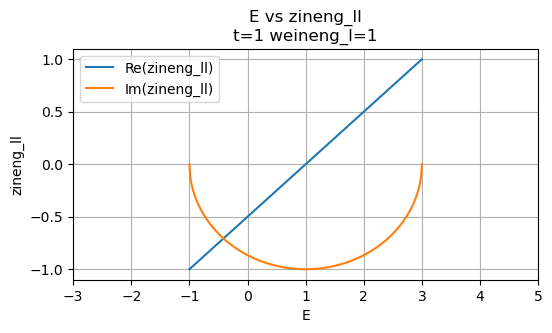

In [97]:

E_array = np.linspace(-3, 5, 601)
real_part = []
imag_part = []

for E in E_array:
    arg = (E - weineng_l) / (2 * t)
    k_l = -np.arccos(arg)       
    z = np.exp(1j * k_l)           
    real_part.append(np.real(z))
    imag_part.append(np.imag(z))

# 绘图
plt.figure(figsize=(6, 3))
plt.plot(E_array, real_part, label='Re(zineng_ll)')
plt.plot(E_array, imag_part, label='Im(zineng_ll)')
plt.xlabel('E')
plt.ylabel('zineng_ll')
plt.title('E vs zineng_ll'+'\n'+rf't={t}'+ rf' weineng_l={weineng_l}')
plt.legend()
plt.grid(True)
plt.xlim(-3,5)
plt.show()